In [1]:
# Install necessary libraries
!pip install nibabel tensorflow matplotlib scikit-image

# Import libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
from skimage.transform import resize
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from keras import backend as K
from keras.callbacks import Callback
from IPython.display import clear_output
from google.colab import drive
import random


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Volume shape: (320, 280, 23)
Slice size (height, width): (320, 280)


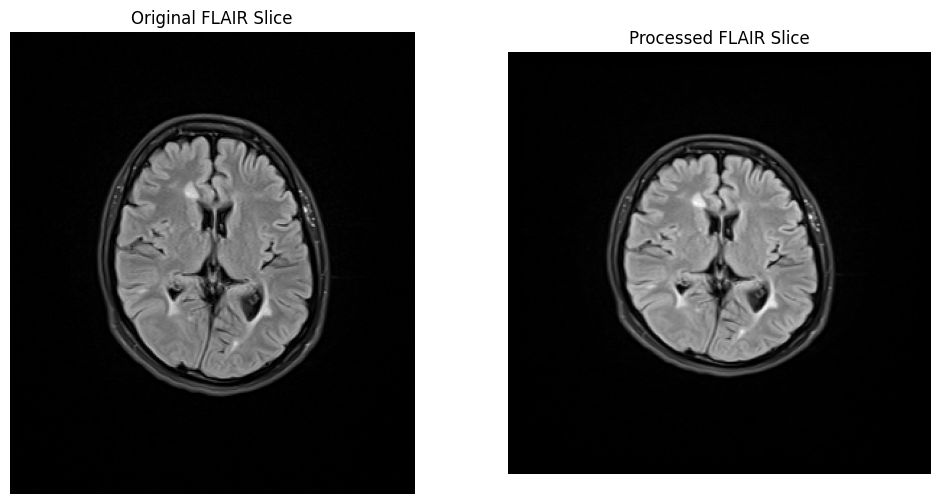

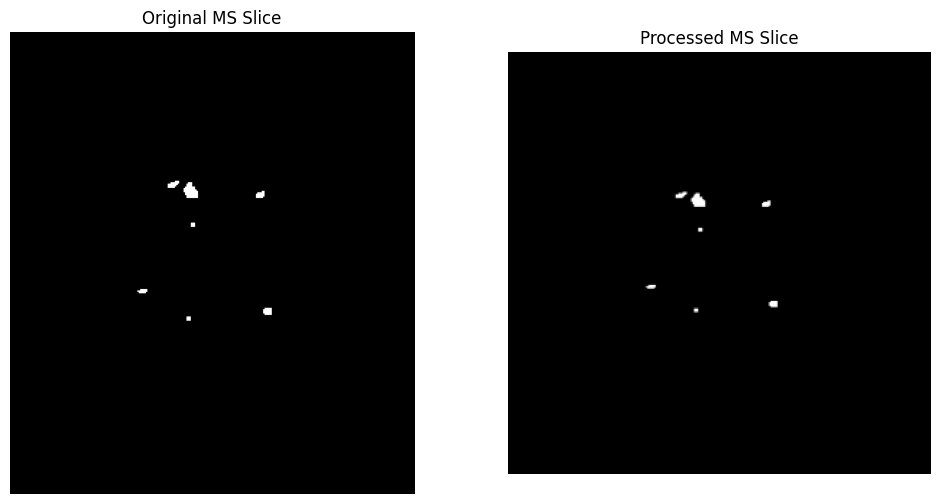

In [2]:

# Mount Google Drive
drive.mount('/content/drive')

# Data loading and preprocessing functions
def load_nii(path):
    nii = nib.load(path)
    return nii.get_fdata()

def pad_image_to_size(image, target_height=320, target_width=320, mode='constant'):
    """Pad the image to the target height and width."""
    current_height, current_width = image.shape[:2]
    delta_h = max(target_height - current_height, 0)
    delta_w = max(target_width - current_width, 0)
    top_pad = delta_h // 2
    bottom_pad = delta_h - top_pad
    left_pad = delta_w // 2
    right_pad = delta_w - left_pad
    padding = ((top_pad, bottom_pad), (left_pad, right_pad))
    padded_image = np.pad(image, padding, mode=mode)
    return padded_image

def preprocess_data(flair_slice, ms_slice, resize_target=(300, 300), pad_target=(320, 320)):
    """Normalize, resize, and pad a single slice of MRI data."""
    # Normalize the FLAIR slice
    flair_normalized = flair_slice / np.max(flair_slice) if np.max(flair_slice) > 0 else flair_slice

    # Binarize the MS slice
    ms_normalized = (ms_slice > 0.5).astype(np.float32)

    # Resize both slices to near target size
    flair_resized = resize(flair_normalized, resize_target, anti_aliasing=True)
    ms_resized = resize(ms_normalized, resize_target, anti_aliasing=True)

    # Pad both slices to ensure exact target dimensions
    flair_padded = pad_image_to_size(flair_resized, *pad_target)
    ms_padded = pad_image_to_size(ms_resized, *pad_target)

    return flair_padded, ms_padded


# Example of loading and preprocessing data
base_path = '/content/drive/My Drive/Semester 10/MS Dataset'
# Data loading and preprocessing code...
patient_number = 2
flair_image_path = f'{base_path}/Patient-{patient_number}/{patient_number}-Flair.nii'
flair_Seg_image_path = f'{base_path}/Patient-{patient_number}/{patient_number}-LesionSeg-Flair.nii'

# Load the FLAIR and MS data
flair_image = nib.load(flair_image_path)
flair_data = flair_image.get_fdata()
MS_image = nib.load(flair_Seg_image_path)
MS_data = MS_image.get_fdata()
volume_shape = flair_data.shape
print("Volume shape:", volume_shape)

# Size of an individual slice
slice_height = volume_shape[0]
slice_width = volume_shape[1]
print("Slice size (height, width):", (slice_height, slice_width))
# Specify the slice index you want to preprocess and visualize
slice_index = flair_data.shape[2] // 2  # or any specific index that is relevant

# Extract the specific slices
flair_slice = flair_data[:, :, slice_index]
MS_slice = MS_data[:, :, slice_index]

# Preprocess the extracted slices

flair_resized, MS_resized = preprocess_data(flair_slice, MS_slice)

# Visualize the original and processed slices
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(flair_slice, cmap='gray')
plt.title('Original FLAIR Slice')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(flair_resized, cmap='gray')
plt.title('Processed FLAIR Slice')
plt.axis('off')

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(MS_slice, cmap='gray')
plt.title('Original MS Slice')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(MS_resized, cmap='gray')
plt.title('Processed MS Slice')
plt.axis('off')

plt.show()


In [ ]:
# Generate dummy data to test the model
num_samples = 10
input_shape = (320, 320, 1)
output_shape_segmentation = (320, 320, 1)
output_shape_classification = (1,)

x_dummy = np.random.random((num_samples,) + input_shape).astype(np.float32)
y_dummy_segmentation = np.random.randint(2, size=(num_samples,) + output_shape_segmentation).astype(np.float32)
y_dummy_classification = np.random.randint(2, size=(num_samples,) + output_shape_classification).astype(np.float32)

# Compile the model
model = extended_unet_model(input_size=input_shape)
model.compile(optimizer='adam',
              loss={'segmentation': dice_loss, 'classification': bce_loss},
              loss_weights={'segmentation': 1., 'classification': 0.5},
              metrics=['accuracy'])

# Train the model
model.fit(x_dummy,
          {'segmentation': y_dummy_segmentation, 'classification': y_dummy_classification},
          epochs=5)



NameError: name 'extended_unet_model' is not defined

In [ ]:
#SKIP IF YOU HAVE DATA

def compile_data(base_path, num_patients):
    """Compile the image data for segmentation and create binary labels for MS presence."""
    combined_images = []
    ms_masks = []
    ms_labels = []

    for patient_number in range(1, num_patients + 1):
        flair_path = os.path.join(base_path, f'Patient-{patient_number}', f'{patient_number}-Flair.nii')
        t2_path = os.path.join(base_path, f'Patient-{patient_number}', f'{patient_number}-T2.nii')
        seg_flair_path = os.path.join(base_path, f'Patient-{patient_number}', f'{patient_number}-LesionSeg-Flair.nii')
        seg_t2_path = os.path.join(base_path, f'Patient-{patient_number}', f'{patient_number}-LesionSeg-T2.nii')

        flair_img = load_nii(flair_path)
        t2_img = load_nii(t2_path)
        ms_flair_img = load_nii(seg_flair_path)
        ms_t2_img = load_nii(seg_t2_path)

        # Iterate over each slice
        for slice_idx in range(flair_img.shape[2]):
            flair_slice = flair_img[:, :, slice_idx]
            ms_slice = ms_flair_img[:, :, slice_idx]

            # Preprocess the flair slice and corresponding mask
            flair_processed, ms_processed = preprocess_data(flair_slice, ms_slice)

            combined_images.append(flair_processed)
            ms_masks.append(ms_processed)

            # Create a binary label based on the presence of lesions
            ms_label = 1 if np.max(ms_slice) > 0 else 0
            ms_labels.append(ms_label)

        for slice_idx in range(t2_img.shape[2]):
            t2_slice = t2_img[:, :, slice_idx]
            ms_slice = ms_t2_img[:, :, slice_idx]
            t2_processed, ms_processed = preprocess_data(t2_slice,ms_slice)
            combined_images.append(t2_processed)
            ms_masks.append(ms_processed)
            # Create a binary label based on the presence of lesions
            ms_label = 1 if np.max(ms_slice) > 0 else 0
            ms_labels.append(ms_label)

    # Convert lists to numpy arrays
    X = np.array(combined_images)
    Y_seg = np.array(ms_masks)
    Y_class = np.array(ms_labels)

    # Ensure proper channel dimension for CNNs
    X = np.expand_dims(X, axis=-1)
    Y_seg = np.expand_dims(Y_seg, axis=-1)

    return X, Y_seg, Y_class

num_patients = 60  # Total number of patients
X, Y_seg, Y_class = compile_data(base_path, num_patients)

base_save_path = '/content/drive/My Drive/Semester 10/MS Dataset/T2_Flair_Data_U-Net'

# Ensure the directory exists
os.makedirs(base_save_path, exist_ok=True)

# Save the arrays
np.save(os.path.join(base_save_path, 'X.npy'), X)
np.save(os.path.join(base_save_path, 'Y_seg.npy'), Y_seg)
np.save(os.path.join(base_save_path, 'Y_class.npy'), Y_class)


In [3]:
base_save_path = '/content/drive/My Drive/Semester 10/MS Dataset/T2_Flair_Data_U-Net'
X = np.load(os.path.join(base_save_path, 'X.npy'))
Y_seg = np.load(os.path.join(base_save_path, 'Y_seg.npy')).astype(np.float32)
Y_class = np.load(os.path.join(base_save_path, 'Y_class.npy')).astype(np.float32)

In [4]:
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, LeakyReLU
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K
import tensorflow as tf
from tensorflow.keras.layers import Concatenate, Cropping2D

from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, LeakyReLU
from tensorflow.keras.models import Model
import tensorflow as tf


def resize_and_concatenate(up_sampled, down_sampled):
    # Assuming up_sampled is smaller than down_sampled
    down_sampled_cropped = Cropping2D(cropping=((0, down_sampled.shape[1] - up_sampled.shape[1]),
                                                 (0, down_sampled.shape[2] - up_sampled.shape[2])))(down_sampled)
    return Concatenate()([up_sampled, down_sampled_cropped])


def print_tensor_shape(tensor, name):
    print(f"{name} shape: {tensor.shape}")
    return tensor


def extended_unet_model(input_size=(320, 320, 1)):
    inputs = Input(input_size)

    # Encoder (downsampling)
    c1 = Conv2D(8, (3, 3), kernel_initializer='he_normal', padding='same')(inputs)
    c1 = LeakyReLU(alpha=0.01)(c1)
    c1 = Conv2D(8, (3, 3), kernel_initializer='he_normal', padding='same')(c1)
    c1 = LeakyReLU(alpha=0.01)(c1)
    p1 = MaxPooling2D((2, 2))(c1)

    c2 = Conv2D(16, (3, 3), kernel_initializer='he_normal', padding='same')(p1)
    c2 = LeakyReLU(alpha=0.01)(c2)
    c2 = Conv2D(16, (3, 3), kernel_initializer='he_normal', padding='same')(c2)
    c2 = LeakyReLU(alpha=0.01)(c2)
    p2 = MaxPooling2D((2, 2))(c2)

    c3 = Conv2D(32, (3, 3), kernel_initializer='he_normal', padding='same')(p2)
    c3 = LeakyReLU(alpha=0.01)(c3)
    c3 = Conv2D(32, (3, 3), kernel_initializer='he_normal', padding='same')(c3)
    c3 = LeakyReLU(alpha=0.01)(c3)
    p3 = MaxPooling2D((2, 2))(c3)

    c4 = Conv2D(64, (3, 3), kernel_initializer='he_normal', padding='same')(p3)
    c4 = LeakyReLU(alpha=0.01)(c4)
    c4 = Conv2D(64, (3, 3), kernel_initializer='he_normal', padding='same')(c4)
    c4 = LeakyReLU(alpha=0.01)(c4)
    p4 = MaxPooling2D(pool_size=(2, 2))(c4)

    # Bottleneck
    c5 = Conv2D(128, (3, 3), kernel_initializer='he_normal', padding='same')(p4)
    c5 = LeakyReLU(alpha=0.01)(c5)
    c5 = Conv2D(128, (3, 3), kernel_initializer='he_normal', padding='same')(c5)
    c5 = LeakyReLU(alpha=0.01)(c5)

    # add 1152
    # Classification branch
    classification = GlobalAveragePooling2D()(c5)
    # add 576
    classification = Dense(1, activation='sigmoid', name='classification')(classification) # modify to help only its layer learn

    # Decoder (upsampling)
    u6 = UpSampling2D((2, 2))(c5)
    u6 = resize_and_concatenate(u6, c4)

    u7 = UpSampling2D((2, 2))(u6)
    u7 = resize_and_concatenate(u7, c3)

    u8 = UpSampling2D((2, 2))(u7)
    u8 = resize_and_concatenate(u8, c2)

    u9 = UpSampling2D((2, 2))(u8)
    u9 = resize_and_concatenate(u9, c1)
    # Segmentation output
    segmentation = Conv2D(1, (1, 1), activation='sigmoid', name='segmentation')(u9)
# Debugging: Print output shapes
    segmentation = print_tensor_shape(segmentation, "Segmentation Output")
    classification = print_tensor_shape(classification, "Classification Output")


    # Create the model with dual outputs
    model = Model(inputs=[inputs], outputs=[segmentation, classification])

    return model


from keras import backend as K

def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)

def bce_loss(y_true, y_pred):
    return K.binary_crossentropy(y_true, y_pred)



In [4]:
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, LeakyReLU
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K
import tensorflow as tf
from tensorflow.keras.layers import Concatenate, Cropping2D

from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, LeakyReLU
from tensorflow.keras.models import Model
import tensorflow as tf


def resize_and_concatenate(up_sampled, down_sampled):
    # Assuming up_sampled is smaller than down_sampled
    down_sampled_cropped = Cropping2D(cropping=((0, down_sampled.shape[1] - up_sampled.shape[1]),
                                                 (0, down_sampled.shape[2] - up_sampled.shape[2])))(down_sampled)
    return Concatenate()([up_sampled, down_sampled_cropped])


def print_tensor_shape(tensor, name):
    print(f"{name} shape: {tensor.shape}")
    return tensor


def extended_unet_model(input_size=(320, 320, 1)):
    inputs = Input(input_size)

    # Encoder (downsampling)
    c1 = Conv2D(8, (3, 3), kernel_initializer='he_normal', padding='same')(inputs)
    c1 = LeakyReLU(alpha=0.01)(c1)
    c1 = Conv2D(8, (3, 3), kernel_initializer='he_normal', padding='same')(c1)
    c1 = LeakyReLU(alpha=0.01)(c1)
    p1 = MaxPooling2D((2, 2))(c1)

    c2 = Conv2D(16, (3, 3), kernel_initializer='he_normal', padding='same')(p1)
    c2 = LeakyReLU(alpha=0.01)(c2)
    c2 = Conv2D(16, (3, 3), kernel_initializer='he_normal', padding='same')(c2)
    c2 = LeakyReLU(alpha=0.01)(c2)
    p2 = MaxPooling2D((2, 2))(c2)

    c3 = Conv2D(32, (3, 3), kernel_initializer='he_normal', padding='same')(p2)
    c3 = LeakyReLU(alpha=0.01)(c3)
    c3 = Conv2D(32, (3, 3), kernel_initializer='he_normal', padding='same')(c3)
    c3 = LeakyReLU(alpha=0.01)(c3)
    p3 = MaxPooling2D((2, 2))(c3)

    c4 = Conv2D(64, (3, 3), kernel_initializer='he_normal', padding='same')(p3)
    c4 = LeakyReLU(alpha=0.01)(c4)
    c4 = Conv2D(64, (3, 3), kernel_initializer='he_normal', padding='same')(c4)
    c4 = LeakyReLU(alpha=0.01)(c4)
    p4 = MaxPooling2D(pool_size=(2, 2))(c4)

    # Bottleneck
    c5 = Conv2D(128, (3, 3), kernel_initializer='he_normal', padding='same')(p4)
    c5 = LeakyReLU(alpha=0.01)(c5)
    c5 = Conv2D(128, (3, 3), kernel_initializer='he_normal', padding='same')(c5)
    c5 = LeakyReLU(alpha=0.01)(c5)

    # add 1152
    # Classification branch
    #classification = GlobalAveragePooling2D()(c5)
    # add 576
    #classification = Dense(1, activation='sigmoid', name='classification')(classification) # modify to help only its layer learn

    # Decoder (upsampling)
    u6 = UpSampling2D((2, 2))(c5)
    u6 = resize_and_concatenate(u6, c4)

    u7 = UpSampling2D((2, 2))(u6)
    u7 = resize_and_concatenate(u7, c3)

    u8 = UpSampling2D((2, 2))(u7)
    u8 = resize_and_concatenate(u8, c2)

    u9 = UpSampling2D((2, 2))(u8)
    u9 = resize_and_concatenate(u9, c1)
    # Segmentation output
    segmentation = Conv2D(1, (1, 1), activation='sigmoid', name='segmentation')(u9)
# Debugging: Print output shapes
    segmentation = print_tensor_shape(segmentation, "Segmentation Output")
    #classification = print_tensor_shape(classification, "Classification Output")


    # Create the model with dual outputs
    model = Model(inputs=[inputs], outputs=[segmentation])

    return model


from keras import backend as K

def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)

def bce_loss(y_true, y_pred):
    return K.binary_crossentropy(y_true, y_pred)



In [ ]:
from tensorflow.keras.layers import Input, Conv2D, LeakyReLU, MaxPooling2D, UpSampling2D, GlobalAveragePooling2D, Dense, BatchNormalization, Dropout
from tensorflow.keras.models import Model

def extended_unet_model(input_size=(320, 320, 1)):
    inputs = Input(input_size)

    # Encoder (downsampling)
    c1 = Conv2D(8, (3, 3), kernel_initializer='he_normal', padding='same')(inputs)
    c1 = BatchNormalization()(c1)
    c1 = LeakyReLU(alpha=0.01)(c1)
    c1 = Conv2D(8, (3, 3), kernel_initializer='he_normal', padding='same')(c1)
    c1 = BatchNormalization()(c1)
    c1 = LeakyReLU(alpha=0.01)(c1)
    p1 = MaxPooling2D((2, 2))(c1)
    p1 = Dropout(0.1)(p1)

    c2 = Conv2D(16, (3, 3), kernel_initializer='he_normal', padding='same')(p1)
    c2 = BatchNormalization()(c2)
    c2 = LeakyReLU(alpha=0.01)(c2)
    c2 = Conv2D(16, (3, 3), kernel_initializer='he_normal', padding='same')(c2)
    c2 = BatchNormalization()(c2)
    c2 = LeakyReLU(alpha=0.01)(c2)
    p2 = MaxPooling2D((2, 2))(c2)
    p2 = Dropout(0.1)(p2)

    c3 = Conv2D(32, (3, 3), kernel_initializer='he_normal', padding='same')(p2)
    c3 = BatchNormalization()(c3)
    c3 = LeakyReLU(alpha=0.01)(c3)
    c3 = Conv2D(32, (3, 3), kernel_initializer='he_normal', padding='same')(c3)
    c3 = BatchNormalization()(c3)
    c3 = LeakyReLU(alpha=0.01)(c3)
    p3 = MaxPooling2D((2, 2))(c3)
    p3 = Dropout(0.2)(p3)

    c4 = Conv2D(64, (3, 3), kernel_initializer='he_normal', padding='same')(p3)
    c4 = BatchNormalization()(c4)
    c4 = LeakyReLU(alpha=0.01)(c4)
    c4 = Conv2D(64, (3, 3), kernel_initializer='he_normal', padding='same')(c4)
    c4 = BatchNormalization()(c4)
    c4 = LeakyReLU(alpha=0.01)(c4)
    p4 = MaxPooling2D(pool_size=(2, 2))(c4)
    p4 = Dropout(0.3)(p4)

    # Bottleneck
    c5 = Conv2D(128, (3, 3), kernel_initializer='he_normal', padding='same')(p4)
    c5 = BatchNormalization()(c5)
    c5 = LeakyReLU(alpha=0.01)(c5)
    c5 = Conv2D(128, (3, 3), kernel_initializer='he_normal', padding='same')(c5)
    c5 = BatchNormalization()(c5)
    c5 = LeakyReLU(alpha=0.01)(c5)

    # Classification branch
    #classification = GlobalAveragePooling2D()(c5)
    #classification = Dense(1, activation='sigmoid', name='classification')(classification)

    # Decoder (upsampling)
    u6 = UpSampling2D((2, 2))(c5)
    u6 = concatenate([u6, c4], axis=3)
    u7 = UpSampling2D((2, 2))(u6)
    u7 = concatenate([u7, c3], axis=3)
    u8 = UpSampling2D((2, 2))(u7)
    u8 = concatenate([u8, c2], axis=3)
    u9 = UpSampling2D((2, 2))(u8)
    u9 = concatenate([u9, c1], axis=3)

    # Segmentation output
    segmentation = Conv2D(1, (1, 1), activation='sigmoid', name='segmentation')(u9)

    # Create the model with dual outputs
    model = Model(inputs=[inputs], outputs=[segmentation])
    return model


In [ ]:
print("shape of X:", X.shape)
print("shape of Y_seg:", Y_seg.shape)
print("shape of Y_class:", Y_class.shape)

shape of X: (2831, 320, 320, 1)
shape of Y_seg: (2831, 320, 320, 1)
shape of Y_class: (2831,)


In [5]:
from sklearn.model_selection import train_test_split

# Split the data into training+validation (80%) and testing (20%)
X_train_val, X_test, Y_seg_train_val, Y_seg_test, Y_class_train_val, Y_class_test = train_test_split(
    X, Y_seg, Y_class, test_size=0.20, random_state=42)

# Further split the training and validation set (from the 80% "train_val" split, allocate 20% to validation)
X_train, X_val, Y_seg_train, Y_seg_val, Y_class_train, Y_class_val = train_test_split(
    X_train_val, Y_seg_train_val, Y_class_train_val, test_size=0.25, random_state=42)

print("Shape of X_train:", X_train.shape)    # This should show the shape of training input images
print("Shape of X_val:", X_val.shape)        # This should show the shape of validation input images
print("Shape of Y_seg_train:", Y_seg_train.shape)  # This should show the shape of training segmentation masks
print("Shape of Y_seg_val:", Y_seg_val.shape)      # This should show the shape of validation segmentation masks
print("Shape of Y_class_train:", Y_class_train.shape)  # This should show the shape of training classification labels
print("Shape of Y_class_val:", Y_class_val.shape)      # This should show the shape of validation classification labels


Shape of X_train: (1698, 320, 320, 1)
Shape of X_val: (566, 320, 320, 1)
Shape of Y_seg_train: (1698, 320, 320, 1)
Shape of Y_seg_val: (566, 320, 320, 1)
Shape of Y_class_train: (1698,)
Shape of Y_class_val: (566,)


In [6]:
import random
import numpy as np
from scipy.ndimage import gaussian_filter, map_coordinates
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
def apply_elastic_deformation(image, alpha=0.3, sigma=0.05, is_mask=False):
    random_state = np.random.RandomState(None)
    shape = image.shape
    dx = gaussian_filter((random_state.rand(*shape) * 2 - 1), sigma, mode="constant", cval=0) * alpha
    dy = gaussian_filter((random_state.rand(*shape) * 2 - 1), sigma, mode="constant", cval=0) * alpha
    dz = np.zeros_like(dx)
    x, y, z = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]), np.arange(shape[2]))
    indices = np.reshape(y+dy, (-1, 1)), np.reshape(x+dx, (-1, 1)), np.reshape(z+dz, (-1, 1))
    deformed_image = map_coordinates(image, indices, order=1).reshape(shape)
    if is_mask:
        # Threshold the mask back to binary values
        deformed_image = (deformed_image > 0.5).astype(np.float32)
    return deformed_image
def random_adjust_brightness_contrast(image, brightness_range=(0.98, 1.0), contrast_range=(1.0, 1.0)):
    brightness_factor = np.random.uniform(*brightness_range)
    contrast_factor = np.random.uniform(*contrast_range)

    adjusted_image = cv2.convertScaleAbs(image, alpha=contrast_factor, beta=0)
    adjusted_image = cv2.convertScaleAbs(adjusted_image, alpha=brightness_factor, beta=0)

    # Add the channel dimension back if it's lost
    if len(adjusted_image.shape) == 2:
        adjusted_image = np.expand_dims(adjusted_image, axis=-1)

    # Re-normalize the image to the range [0, 1] by dividing by the max pixel value
    max_val = np.max(adjusted_image)
    if max_val > 0:
        adjusted_image = adjusted_image / max_val

    return adjusted_image



def custom_augmentation(image, mask):
    augmentations = [
        ('elastic_deformation', apply_elastic_deformation),
        ('brightness_contrast', random_adjust_brightness_contrast)
    ]
    decision = random.random()
    if decision < 0.25:
        # No augmentation will be applied
        pass
    elif decision < 0.75:
        # Only one augmentation will be applied
        augmentation_to_apply = random.choice(augmentations[:1])  # Choose only geometric transformations
        aug_name, augmentation = augmentation_to_apply
        if aug_name == 'elastic_deformation':
            image = augmentation(image, is_mask=False)
            mask = augmentation(mask, is_mask=True)
    else:
        # A combination of augmentations will be applied
        random.shuffle(augmentations)
        for aug_name, augmentation in augmentations:
            if random.random() > 0.5:
                if aug_name == 'elastic_deformation':
                    image = augmentation(image, is_mask=False)
                    mask = augmentation(mask, is_mask=True)
                elif aug_name in ['brightness_contrast']:
                    image = augmentation(image)  # Apply only to image for intensity transformations

    return image, mask
# Data augmentation for training
train_datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    preprocessing_function=custom_augmentation  # Unified custom augmentation function
)
# Example usage within the data generator:
def train_generator(X_train, Y_seg_train, Y_class_train, batch_size):
    # Calculate the number of steps per epoch
    steps_per_epoch = np.ceil(len(X_train) / batch_size)
    current_index = 0

    while True:
        # Determine the range for the current batch
        start_index = current_index
        end_index = start_index + batch_size
        current_index += batch_size

        # If the end index exceeds the length of the dataset, wrap around
        if end_index > len(X_train):
            end_index = len(X_train)
            current_index = 0  # Reset for the next epoch

        # Slice the batch
        batch_X = X_train[start_index:end_index]
        batch_Y_seg = Y_seg_train[start_index:end_index]
        batch_Y_class = Y_class_train[start_index:end_index]

        # Apply custom augmentations
        for i in range(len(batch_X)):
            batch_X[i], batch_Y_seg[i] = custom_augmentation(batch_X[i], batch_Y_seg[i])

        yield batch_X, [batch_Y_seg, batch_Y_class]

# No augmentation for validation
val_datagen = ImageDataGenerator()
def validation_generator(X_val, Y_seg_val, Y_class_val, batch_size):
    seed = 42
    image_gen = val_datagen.flow(X_val, batch_size=batch_size, seed=seed, shuffle=False)
    mask_gen = val_datagen.flow(Y_seg_val, batch_size=batch_size, seed=seed, shuffle=False)
    while True:
        #print(f"Current index: {image_gen.batch_index}, Batch size: {batch_size}")
        images = next(image_gen)
        masks = next(mask_gen)
        # Get the current index (assuming it's the same for both generators)
        current_index = (image_gen.batch_index - 1) * batch_size
        if current_index < 0:  # In case batch_index is 0
            current_index = 0
        # Adjust the end index for the final batch
        end_index = current_index + batch_size
        if end_index > len(Y_class_val):
            end_index = len(Y_class_val)
        class_labels = Y_class_val[current_index:end_index]
        # Ensure the batch size is consistent across inputs and labels
        if len(images) != len(class_labels) or len(images) != len(masks):
            #print("Mismatch in batch sizes detected. Adjusting batch...")
            min_batch_size = min(len(images), len(masks), len(class_labels))
            images = images[:min_batch_size]
            masks = masks[:min_batch_size]
            class_labels = class_labels[:min_batch_size]
        yield images, [masks, class_labels]






# Example usage
#train_flow = train_generator(X_train, Y_seg_train, Y_class_train, batch_size=2)
#val_flow = validation_generator(X_val, Y_seg_val, Y_class_val, batch_size=2)

Training batch shapes:
Images shape: (10, 320, 320, 1)
Segmentation masks shape: (10, 320, 320, 1)
Classification labels shape: (10,)

Validation batch shapes:
Images shape: (10, 320, 320, 1)
Segmentation masks shape: (10, 320, 320, 1)
Classification labels shape: (10,)


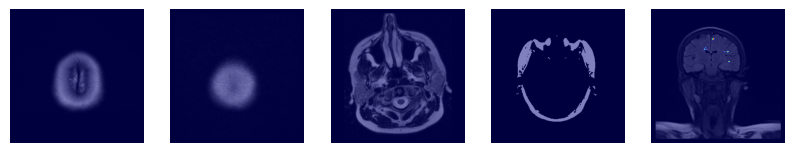

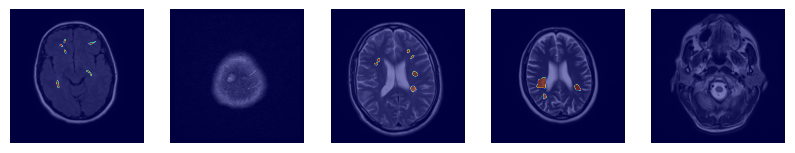

In [ ]:
#FOR TESTING PURPOSES
# Define batch size
batch_size = 10

# Create the generators
train_gen = train_generator(X_train, Y_seg_train, Y_class_train, batch_size)
val_gen = validation_generator(X_val, Y_seg_val, Y_class_val, batch_size)

# Fetch a batch from the training generator and display the shapes
train_images, [train_masks, train_class_labels] = next(train_gen)
print("Training batch shapes:")
print("Images shape:", train_images.shape)
print("Segmentation masks shape:", train_masks.shape)
print("Classification labels shape:", train_class_labels.shape)

# Fetch a batch from the validation generator and display the shapes
val_images, [val_masks, val_class_labels] = next(val_gen)
print("\nValidation batch shapes:")
print("Images shape:", val_images.shape)
print("Segmentation masks shape:", val_masks.shape)
print("Classification labels shape:", val_class_labels.shape)
import matplotlib.pyplot as plt

# Display images with masks
def display_images_with_masks(images, masks, num_display=5):
    plt.figure(figsize=(10, 10))
    for i in range(num_display):
        plt.subplot(1, num_display, i+1)
        plt.imshow(images[i, :, :, 0], cmap='gray')
        plt.imshow(masks[i, :, :, 0], alpha=0.5, cmap='jet')
        plt.axis('off')
    plt.show()

# Display a few training images with masks
display_images_with_masks(train_images, train_masks)
''
# Display a few validation images with masks
display_images_with_masks(val_images, val_masks)



In [ ]:
# Example code to train on a single batch
single_batch_images, [single_batch_masks, single_batch_class_labels] = next(train_gen)
model.train_on_batch(single_batch_images, [single_batch_masks, single_batch_class_labels])


[1.4066059589385986,
 0.9975622296333313,
 0.8180874586105347,
 0.0008886719006113708,
 0.30000001192092896]

In [ ]:
# Define the number of epochs and batch size
epochs = 5
batch_size = 10

# Create the model
model = extended_unet_model(input_size=(320, 320, 1))



# Compile the model with the Dice coefficient as a metric
model.compile(optimizer='adam',
              loss={'segmentation': dice_loss, 'classification': bce_loss},
              loss_weights={'segmentation': 1., 'classification': 0.5},
              metrics={'segmentation': dice_coefficient, 'classification': 'accuracy'})


# Fit the model using the data generators
history = model.fit(
    train_generator(X_train, Y_seg_train, Y_class_train, batch_size),
    steps_per_epoch=len(X_train) // batch_size,
    validation_data=validation_generator(X_val, Y_seg_val, Y_class_val, batch_size),
    validation_steps=len(X_val) // batch_size,
    epochs=epochs
)


Segmentation Output shape: (None, 320, 320, 1)
Classification Output shape: (None, 20, 20, 1)
Epoch 1/5


ValueError: in user code:

    File "/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py", line 1401, in train_function  *
        return step_function(self, iterator)
    File "<ipython-input-10-bd60373eb0d9>", line 101, in bce_loss  *
        return K.binary_crossentropy(y_true, y_pred)
    File "/usr/local/lib/python3.10/dist-packages/keras/src/backend.py", line 5822, in binary_crossentropy
        return tf.nn.sigmoid_cross_entropy_with_logits(

    ValueError: `logits` and `labels` must have the same shape, received ((None, None, None, 1) vs (None,)).


In [ ]:
def plot_training_history(history):
    plt.figure(figsize=(12, 4))

    # Plot training & validation loss values
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss Over Epochs')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()

    # Plot training & validation Dice coefficient values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['segmentation_dice_coefficient'], label='Training Segmentation Dice')
    plt.plot(history.history['val_segmentation_dice_coefficient'], label='Validation Segmentation Dice')
    plt.plot(history.history['classification_accuracy'], label='Training Classification Accuracy')
    plt.plot(history.history['val_classification_accuracy'], label='Validation Classification Accuracy')
    plt.title('Dice Coefficient Over Epochs')
    plt.ylabel('Dice Coefficient')
    plt.xlabel('Epoch')
    plt.legend()

    plt.show()

plot_training_history(history)


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
# Define the early stopping callback
early_stopper = EarlyStopping(
    monitor='val_loss',   # Metric to monitor
    min_delta=0.01,      # Minimum change to qualify as an improvement
    patience=10,          # Number of epochs with no improvement after which training will be stopped
    verbose=1,            # Output messages
    restore_best_weights=True  # Restores model weights from the epoch with the best value of the monitored quantity
)

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import BinaryAccuracy, MeanIoU
from tensorflow.keras.losses import BinaryCrossentropy


# Assuming PlotDualLosses and other necessary imports are defined elsewhere
epochs = 5
batch_size = 25
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

loss_weights_options = [
    {'segmentation': 1.0, 'classification': 0.5},
    {'segmentation': 0.7, 'classification': 0.3},
    {'segmentation': 0.5, 'classification': 0.5}
]
learning_rate_options = [0.001, 0.0001]

best_val_accuracy = -np.inf
best_config = None

results = []

for loss_weights in loss_weights_options:
    for lr in learning_rate_options:
        print(f"Training with loss_weights={loss_weights} and learning_rate={lr}")

        # Initialize and compile the model with current hyperparameters
        model = extended_unet_model()
        optimizer = Adam(learning_rate=lr)
        model.compile(
            optimizer=optimizer,
            loss={'segmentation': dice_loss, 'classification': bce_loss},
            loss_weights=loss_weights,
            metrics={'segmentation': dice_coefficient, 'classification': 'accuracy'}
        )

        # Setup callbacks
        early_stopping = EarlyStopping(monitor='val_classification_accuracy', patience=5, verbose=1, restore_best_weights=True, mode='max')

        # Fit the model
        history = model.fit(
            train_generator(X_train, Y_seg_train, Y_class_train, batch_size),
            steps_per_epoch=len(X_train) // batch_size,
            validation_data=validation_generator(X_val, Y_seg_val, Y_class_val, batch_size),
            validation_steps=len(X_val) // batch_size,
            epochs=epochs,
            callbacks=[early_stopping],
            verbose=1  # Set verbose to 0 for less output during training
        )

        # Extract the best validation accuracy achieved during the training
        val_accuracy = np.max(history.history['val_classification_accuracy'])

        results.append({
            'loss_weights': loss_weights,
            'learning_rate': lr,
            'validation_accuracy': val_accuracy
        })

        # Update the best configuration if found
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_config = {
                'loss_weights': loss_weights,
                'learning_rate': lr,
                'validation_accuracy': val_accuracy
            }

print("Best configuration found:")
print(best_config)
# Optionally, save the results to a file for further analysis
# import pandas as pd
# results_df = pd.DataFrame(results)
# results_df.to_csv('grid_search_results.csv', index=False)



Training with loss_weights={'segmentation': 1.0, 'classification': 0.5} and learning_rate=0.001
Segmentation Output shape: (None, 320, 320, 1)
Classification Output shape: (None, 1)
Epoch 1/5
67/67 [==============================] - 48s 676ms/step - loss: 1.3527 - segmentation_loss: 0.9956 - classification_loss: 0.7142 - segmentation_dice_coefficient: 0.0044 - classification_accuracy: 0.5236 - val_loss: 1.3349 - val_segmentation_loss: 0.9940 - val_classification_loss: 0.6817 - val_segmentation_dice_coefficient: 0.0060 - val_classification_accuracy: 0.5636
Epoch 2/5
67/67 [==============================] - 46s 700ms/step - loss: 1.3289 - segmentation_loss: 0.9935 - classification_loss: 0.6707 - segmentation_dice_coefficient: 0.0065 - classification_accuracy: 0.6013 - val_loss: 1.3334 - val_segmentation_loss: 0.9924 - val_classification_loss: 0.6821 - val_segmentation_dice_coefficient: 0.0077 - val_classification_accuracy: 0.5712
Epoch 3/5
67/67 [==============================] - 45s 681

KeyboardInterrupt: 

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.metrics import BinaryAccuracy, MeanIoU
from tensorflow.keras.losses import BinaryCrossentropy

# Assuming PlotDualLosses and other necessary imports are defined elsewhere
epochs = 5
batch_sizes = [10, 25, 32, 50]  # Different batch sizes to test

# Fixed learning rate and loss weights
fixed_learning_rate = 0.001  # Replace with your chosen fixed learning rate
fixed_loss_weights = {'segmentation': 1.0, 'classification': 0.5}  # Replace with your chosen fixed loss weights

best_val_accuracy = -np.inf
best_batch_size = None

results = []

for batch_size in batch_sizes:
    print(f"Training with batch_size={batch_size}")

    # Initialize and compile the model with current hyperparameters
    model = extended_unet_model()
    optimizer = Adam(learning_rate=fixed_learning_rate)
    model.compile(
        optimizer=optimizer,
        loss={'segmentation': dice_loss, 'classification': bce_loss},
        loss_weights=fixed_loss_weights,
        metrics={'segmentation': dice_coefficient, 'classification': 'accuracy'}
    )

    # Setup callbacks
    early_stopping = EarlyStopping(monitor='val_classification_accuracy', patience=5, verbose=1, restore_best_weights=True, mode='max')

    # Fit the model
    history = model.fit(
        train_generator(X_train, Y_seg_train, Y_class_train, batch_size),
        steps_per_epoch=len(X_train) // batch_size,
        validation_data=validation_generator(X_val, Y_seg_val, Y_class_val, batch_size),
        validation_steps=len(X_val) // batch_size,
        epochs=epochs,
        callbacks=[early_stopping],
        verbose=1
    )

    # Extract the best validation accuracy achieved during the training
    val_accuracy = np.max(history.history['val_classification_accuracy'])

    results.append({
        'batch_size': batch_size,
        'validation_accuracy': val_accuracy
    })

    # Update the best configuration if found
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_batch_size = batch_size

print("Best batch size found:", best_batch_size)

# Optionally, save the results to a file for further analysis
# import pandas as pd
# results_df = pd.DataFrame(results)
# results_df.to_csv('batch_size_search_results.csv', index=False)


Training with batch_size=10
Segmentation Output shape: (None, 320, 320, 1)
Classification Output shape: (None, 1)
Epoch 1/5
169/169 [==============================] - 50s 274ms/step - loss: 1.3379 - segmentation_loss: 0.9952 - classification_loss: 0.6854 - segmentation_dice_coefficient: 0.0048 - classification_accuracy: 0.5527 - val_loss: 1.3151 - val_segmentation_loss: 0.9922 - val_classification_loss: 0.6457 - val_segmentation_dice_coefficient: 0.0078 - val_classification_accuracy: 0.5821
Epoch 2/5
169/169 [==============================] - 48s 276ms/step - loss: 1.2907 - segmentation_loss: 0.9884 - classification_loss: 0.6046 - segmentation_dice_coefficient: 0.0116 - classification_accuracy: 0.6925 - val_loss: 1.2830 - val_segmentation_loss: 0.9700 - val_classification_loss: 0.6262 - val_segmentation_dice_coefficient: 0.0299 - val_classification_accuracy: 0.6835
Epoch 3/5
169/169 [==============================] - 47s 277ms/step - loss: 1.2434 - segmentation_loss: 0.9663 - classific

In [7]:
class PlotDualLosses(Callback):
    def __init__(self, figure_size=(12, 6)):
        super().__init__()
        self.figure_size = figure_size

    def on_train_begin(self, logs=None):
        self.i = 0
        self.x = []
        self.losses = []
        self.val_losses = []
        self.segmentation_dice_coefficient = []
        self.val_segmentation_dice_coefficient = []
        self.classification_accuracy = []
        self.val_classification_accuracy = []
        self.logs = []

    def on_epoch_end(self, epoch, logs=None):
        self.logs.append(logs)
        self.x.append(self.i)
        self.losses.append(logs.get('loss', 0))
        self.val_losses.append(logs.get('val_loss', 0))
        self.segmentation_dice_coefficient.append(logs.get('segmentation_dice_coefficient', 0))
        self.val_segmentation_dice_coefficient.append(logs.get('val_segmentation_dice_coefficient', 0))
        self.classification_accuracy.append(logs.get('classification_accuracy', 0))
        self.val_classification_accuracy.append(logs.get('val_classification_accuracy', 0))
        self.i += 1

        clear_output(wait=True)
        plt.figure(figsize=self.figure_size)
        plt.subplot(3, 1, 1)
        plt.plot(self.x, self.losses, label="Training loss")
        plt.plot(self.x, self.val_losses, label="Validation loss")
        plt.legend()
        plt.title('Training and Validation Loss')

        plt.subplot(3, 1, 2)
        plt.plot(self.x, self.segmentation_dice_coefficient, label="Training Segmentation Dice Coefficient")
        plt.plot(self.x, self.val_segmentation_dice_coefficient, label="Validation Segmentation Dice Coefficient")
        plt.legend()
        plt.title('Training and Validation Dice Coefficient for Segmentation')

        plt.subplot(3, 1, 3)
        plt.plot(self.x, self.classification_accuracy, label="Training Classification Accuracy")
        plt.plot(self.x, self.val_classification_accuracy, label="Validation Classification Accuracy")
        plt.legend()
        plt.title('Training and Validation Accuracy for Classification')

        plt.tight_layout()
        plt.show()



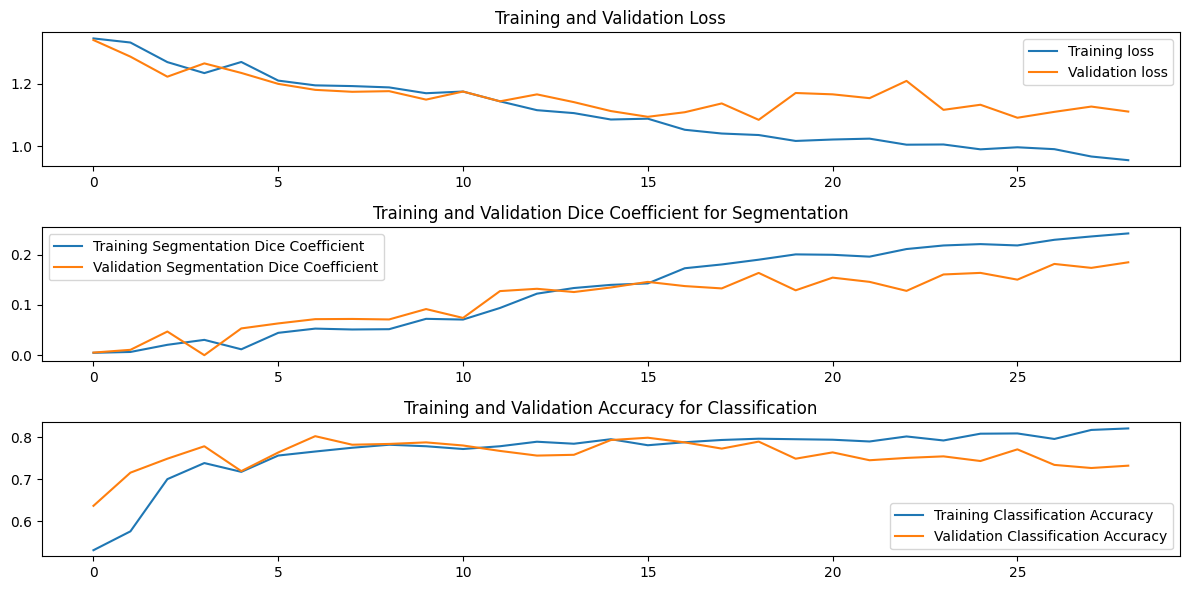


Epoch 29: val_loss did not improve from 1.08392
67/67 [==============================] - 47s 705ms/step - loss: 0.9548 - segmentation_loss: 0.7580 - classification_loss: 0.3936 - segmentation_dice_coefficient: 0.2422 - classification_accuracy: 0.8207 - val_loss: 1.1103 - val_segmentation_loss: 0.8161 - val_classification_loss: 0.5885 - val_segmentation_dice_coefficient: 0.1848 - val_classification_accuracy: 0.7320
Best validation accuracy with batch size 25: 0.8022181391716003


In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import BinaryAccuracy, MeanIoU
from tensorflow.keras.losses import BinaryCrossentropy

# Assuming PlotDualLosses and other necessary imports are defined elsewhere
epochs = 50
batch_size = 25  # Optimal batch size determined from experiments

# Fixed learning rate and loss weights
fixed_learning_rate = 0.001  # Replace with your chosen fixed learning rate
fixed_loss_weights = {'segmentation': 1.0, 'classification': 0.5}  # Replace with your chosen fixed loss weights

# Initialize and compile the model with current hyperparameters
model = extended_unet_model()
optimizer = Adam(learning_rate=fixed_learning_rate)
model.compile(
    optimizer=optimizer,
    loss={'segmentation': dice_loss, 'classification': bce_loss},
    loss_weights=fixed_loss_weights,
    metrics={'segmentation': dice_coefficient, 'classification': 'accuracy'}
)

# Setup callbacks
early_stopping = EarlyStopping(monitor='val_classification_accuracy', patience=5, verbose=1, restore_best_weights=True, mode='max')

early_stopping = EarlyStopping(monitor='val_loss', patience=10)

# Setup the plot losses callback
plot_dual_losses = PlotDualLosses()
from tensorflow.keras.callbacks import ModelCheckpoint

# Setup model checkpointing
checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)
# Fit the model
history = model.fit(
    train_generator(X_train, Y_seg_train, Y_class_train, batch_size),
    steps_per_epoch=len(X_train) // batch_size,
    validation_data=validation_generator(X_val, Y_seg_val, Y_class_val, batch_size),
    validation_steps=len(X_val) // batch_size,
    epochs=epochs,
    callbacks=[plot_dual_losses, early_stopping, checkpoint],
    verbose=1
)

# Extract the best validation accuracy achieved during the training
best_val_accuracy = np.max(history.history['val_classification_accuracy'])

print(f"Best validation accuracy with batch size {batch_size}:", best_val_accuracy)


In [ ]:
#Implement in a way where classification loss is only used on layer connected to bottle neck layer (maybe fully connected layers)

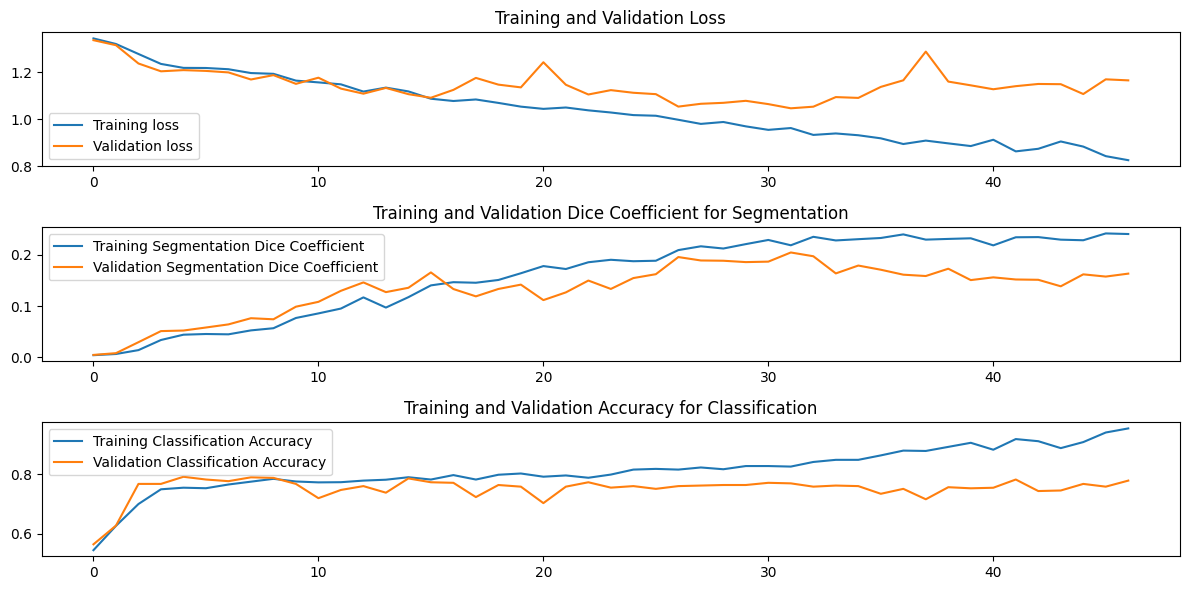


Epoch 47: val_loss did not improve from 1.04688
67/67 [==============================] - 42s 639ms/step - loss: 0.8259 - segmentation_loss: 0.7603 - classification_loss: 0.1312 - segmentation_dice_coefficient: 0.2400 - classification_accuracy: 0.9540 - val_loss: 1.1658 - val_segmentation_loss: 0.8378 - val_classification_loss: 0.6561 - val_segmentation_dice_coefficient: 0.1630 - val_classification_accuracy: 0.7782
Best validation accuracy with batch size 25: 0.7911275625228882


In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import BinaryAccuracy, MeanIoU
from tensorflow.keras.losses import BinaryCrossentropy

# Assuming PlotDualLosses and other necessary imports are defined elsewhere
epochs = 50
batch_size = 25  # Optimal batch size determined from experiments

# Fixed learning rate and loss weights
fixed_learning_rate = 0.001  # Replace with your chosen fixed learning rate
fixed_loss_weights = {'segmentation': 1.0, 'classification': 0.5}  # Replace with your chosen fixed loss weights

# Initialize and compile the model with current hyperparameters
model = extended_unet_model()
optimizer = Adam(learning_rate=fixed_learning_rate)
model.compile(
    optimizer=optimizer,
    loss={'segmentation': dice_loss, 'classification': bce_loss},
    loss_weights=fixed_loss_weights,
    metrics={'segmentation': dice_coefficient, 'classification': 'accuracy'}
)

# Setup callbacks
early_stopping = EarlyStopping(monitor='val_classification_accuracy', patience=5, verbose=1, restore_best_weights=True, mode='max')

early_stopping = EarlyStopping(monitor='val_loss', patience=15)

# Setup the plot losses callback
plot_dual_losses = PlotDualLosses()
from tensorflow.keras.callbacks import ModelCheckpoint

# Setup model checkpointing
checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)
# Fit the model
history = model.fit(
    train_generator(X_train, Y_seg_train, Y_class_train, batch_size),
    steps_per_epoch=len(X_train) // batch_size,
    validation_data=validation_generator(X_val, Y_seg_val, Y_class_val, batch_size),
    validation_steps=len(X_val) // batch_size,
    epochs=epochs,
    callbacks=[plot_dual_losses, early_stopping, checkpoint],
    verbose=1
)

# Extract the best validation accuracy achieved during the training
best_val_accuracy = np.max(history.history['val_classification_accuracy'])

print(f"Best validation accuracy with batch size {batch_size}:", best_val_accuracy)


In [8]:
class DynamicLossWeights(tf.keras.callbacks.Callback):
    def __init__(self, initial_alpha=0.5, initial_beta=0.5, monitor='val_loss', mode='min', factor=0.05):
        super(DynamicLossWeights, self).__init__()
        self.alpha = initial_alpha
        self.beta = initial_beta
        self.monitor = monitor
        self.mode = mode
        self.factor = factor
        self.best = np.Inf if mode == 'min' else -np.Inf

    def on_epoch_end(self, epoch, logs=None):
        current = logs.get(self.monitor)
        if current is None:
            return

        if (self.mode == 'min' and current < self.best) or (self.mode == 'max' and current > self.best):
            self.best = current
            # Adjust alpha and beta based on your strategy
            # Example: Increase alpha to prioritize BCE if performance improves
            self.alpha += self.factor
            self.beta -= self.factor
            # Ensure alpha and beta sum to 1
            total = self.alpha + self.beta
            self.alpha /= total
            self.beta /= total

            # Print the new weights for visibility
            print(f'Updated loss weights - Alpha: {self.alpha}, Beta: {self.beta}')

        # Update the loss function of the model
        self.model.loss = weighted_bce_dice_loss(self.alpha, self.beta)


In [27]:
import numpy as np
import tensorflow as tf

class AdaptiveLossWeights(tf.keras.callbacks.Callback):
    def __init__(self, initial_alpha=0.5, initial_beta=0.5, monitor='val_loss', mode='min', factor=0.01, momentum=0.9):
        super(AdaptiveLossWeights, self).__init__()
        self.alpha = initial_alpha
        self.beta = initial_beta
        self.monitor = monitor
        self.mode = mode
        self.factor = factor
        self.momentum = momentum
        self.alpha_velocity = 0
        self.beta_velocity = 0
        self.best = np.Inf if mode == 'min' else -np.Inf

    def on_epoch_end(self, epoch, logs=None):
        current = logs.get(self.monitor)
        if current is None:
            return

        if (self.mode == 'min' and current < self.best) or (self.mode == 'max' and current > self.best):
            self.best = current

            # Calculate velocity updates
            self.alpha_velocity = self.momentum * self.alpha_velocity + (1 - self.momentum) * self.factor
            self.beta_velocity = self.momentum * self.beta_velocity - (1 - self.momentum) * self.factor

            # Update alpha and beta with velocity
            self.alpha += self.alpha_velocity
            self.beta += self.beta_velocity

            # Normalize to keep the sum of alpha and beta equal to 1
            total = self.alpha + self.beta
            self.alpha /= total
            self.beta /= total

            # Print the new weights for visibility
            print(f'Updated loss weights - Alpha: {self.alpha}, Beta: {self.beta}')

    # Ensure the updated loss function is used with the new weights
    def on_train_batch_begin(self, batch, logs=None):
        self.model.loss = weighted_bce_dice_loss(self.alpha, self.beta)

def weighted_bce_dice_loss(alpha, beta):
    def loss(y_true, y_pred):
        bce = tf.keras.losses.BinaryCrossentropy()
        dice_loss_value = dice_loss(y_true, y_pred)  # Ensure dice_loss is defined elsewhere

        combined_loss = alpha * bce(y_true, y_pred) + beta * dice_loss_value
        return combined_loss
    return loss

# Ensure to define dice_loss function as well as how to initialize and train your model


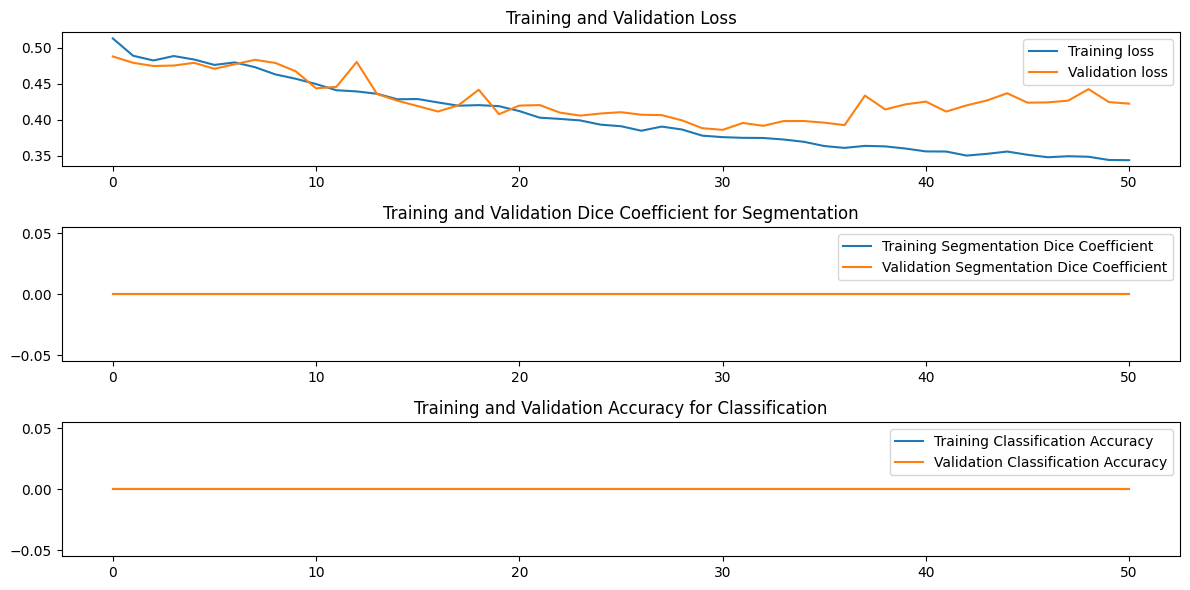


Epoch 51: val_loss did not improve from 0.38609
67/67 [==============================] - 43s 643ms/step - loss: 0.3439 - dice_coefficient: 0.3351 - val_loss: 0.4225 - val_dice_coefficient: 0.1711
Best validation accuracy with batch size 25: 0.24693018198013306


In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import BinaryAccuracy, MeanIoU
from tensorflow.keras.losses import BinaryCrossentropy

# Assuming PlotDualLosses and other necessary imports are defined elsewhere
epochs = 200
batch_size = 25  # Optimal batch size determined from experiments

def weighted_bce_dice_loss(alpha, beta):
    def loss(y_true, y_pred):
        bce = tf.keras.losses.BinaryCrossentropy()
        dice_loss_value = dice_loss(y_true, y_pred)  # Ensure dice_loss is defined elsewhere

        combined_loss = alpha * bce(y_true, y_pred) + beta * dice_loss_value
        return combined_loss
    return loss
dynamic_loss_weights = DynamicLossWeights()
# Fixed learning rate and loss weights
fixed_learning_rate = 0.001  # Replace with your chosen fixed learning rate
  # Replace with your chosen fixed loss weights

# Initialize and compile the model with current hyperparameters
model = extended_unet_model()
optimizer = Adam(learning_rate=fixed_learning_rate)
model.compile(
    optimizer=optimizer,
    loss={'segmentation': weighted_bce_dice_loss(0.5, 0.5)},

    metrics={'segmentation': dice_coefficient}
)

# Setup callbacks
early_stopping = EarlyStopping(monitor='val_classification_accuracy', patience=5, verbose=1, restore_best_weights=True, mode='max')

early_stopping = EarlyStopping(monitor='val_loss', patience=20)

# Setup the plot losses callback
plot_dual_losses = PlotDualLosses()
from tensorflow.keras.callbacks import ModelCheckpoint

# Setup model checkpointing
checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)
# Fit the model
history = model.fit(
    train_generator(X_train, Y_seg_train, Y_class_train, batch_size),
    steps_per_epoch=len(X_train) // batch_size,
    validation_data=validation_generator(X_val, Y_seg_val, Y_class_val, batch_size),
    validation_steps=len(X_val) // batch_size,
    epochs=epochs,
    callbacks=[plot_dual_losses, early_stopping, checkpoint,dynamic_loss_weights],
    verbose=1

)

# Extract the best validation accuracy achieved during the training
best_val_accuracy = np.max(history.history['val_dice_coefficient'])

print(f"Best validation accuracy with batch size {batch_size}:", best_val_accuracy)


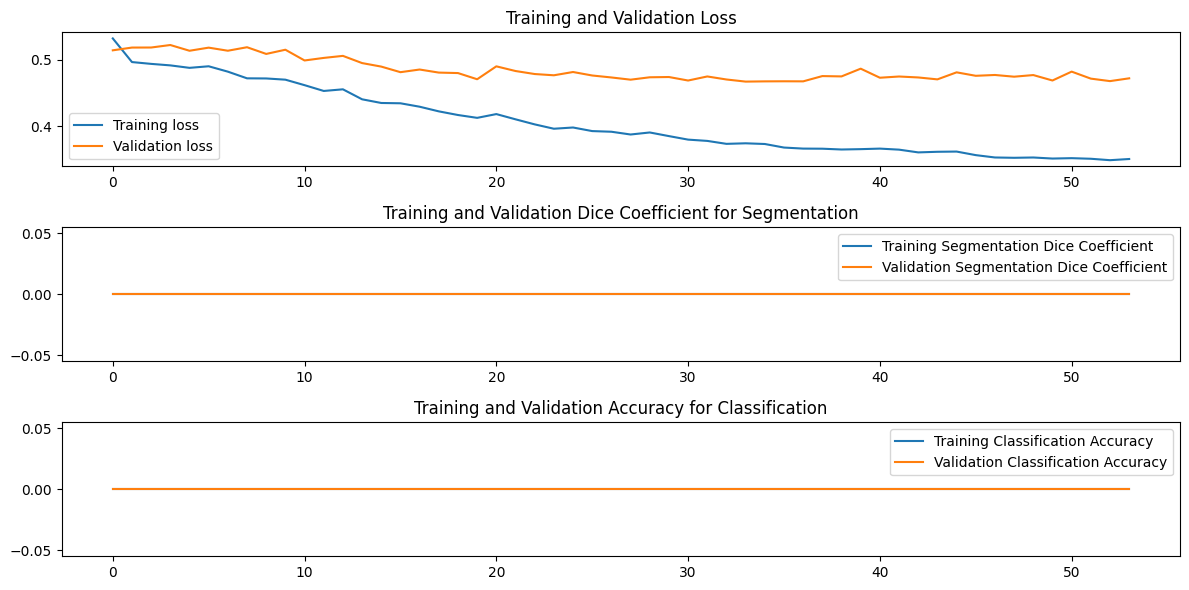


Epoch 54: val_loss did not improve from 0.46710
67/67 [==============================] - 43s 654ms/step - loss: 0.3507 - dice_coefficient: 0.3208 - val_loss: 0.4720 - val_dice_coefficient: 0.0793
Best validation accuracy with batch size 25: 0.0888848602771759


In [28]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import BinaryAccuracy, MeanIoU
from tensorflow.keras.losses import BinaryCrossentropy

# Assuming PlotDualLosses and other necessary imports are defined elsewhere
epochs = 200
batch_size = 25  # Optimal batch size determined from experiments

def weighted_bce_dice_loss(alpha, beta):
    def loss(y_true, y_pred):
        bce = tf.keras.losses.BinaryCrossentropy()
        dice_loss_value = dice_loss(y_true, y_pred)  # Ensure dice_loss is defined elsewhere

        combined_loss = alpha * bce(y_true, y_pred) + beta * dice_loss_value
        return combined_loss
    return loss
dynamic_loss_weights = AdaptiveLossWeights()
# Fixed learning rate and loss weights
fixed_learning_rate = 0.001  # Replace with your chosen fixed learning rate
  # Replace with your chosen fixed loss weights

# Initialize and compile the model with current hyperparameters
model = extended_unet_model()
optimizer = Adam(learning_rate=fixed_learning_rate)
model.compile(
    optimizer=optimizer,
    loss={'segmentation': weighted_bce_dice_loss(0.5, 0.5)},

    metrics={'segmentation': dice_coefficient}
)

# Setup callbacks
early_stopping = EarlyStopping(monitor='val_classification_accuracy', patience=5, verbose=1, restore_best_weights=True, mode='max')

early_stopping = EarlyStopping(monitor='val_loss', patience=20)

# Setup the plot losses callback
plot_dual_losses = PlotDualLosses()
from tensorflow.keras.callbacks import ModelCheckpoint

# Setup model checkpointing
checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)
# Fit the model
history = model.fit(
    train_generator(X_train, Y_seg_train, Y_class_train, batch_size),
    steps_per_epoch=len(X_train) // batch_size,
    validation_data=validation_generator(X_val, Y_seg_val, Y_class_val, batch_size),
    validation_steps=len(X_val) // batch_size,
    epochs=epochs,
    callbacks=[plot_dual_losses, early_stopping, checkpoint,dynamic_loss_weights],
    verbose=1

)

# Extract the best validation accuracy achieved during the training
best_val_accuracy = np.max(history.history['val_dice_coefficient'])

print(f"Best validation accuracy with batch size {batch_size}:", best_val_accuracy)


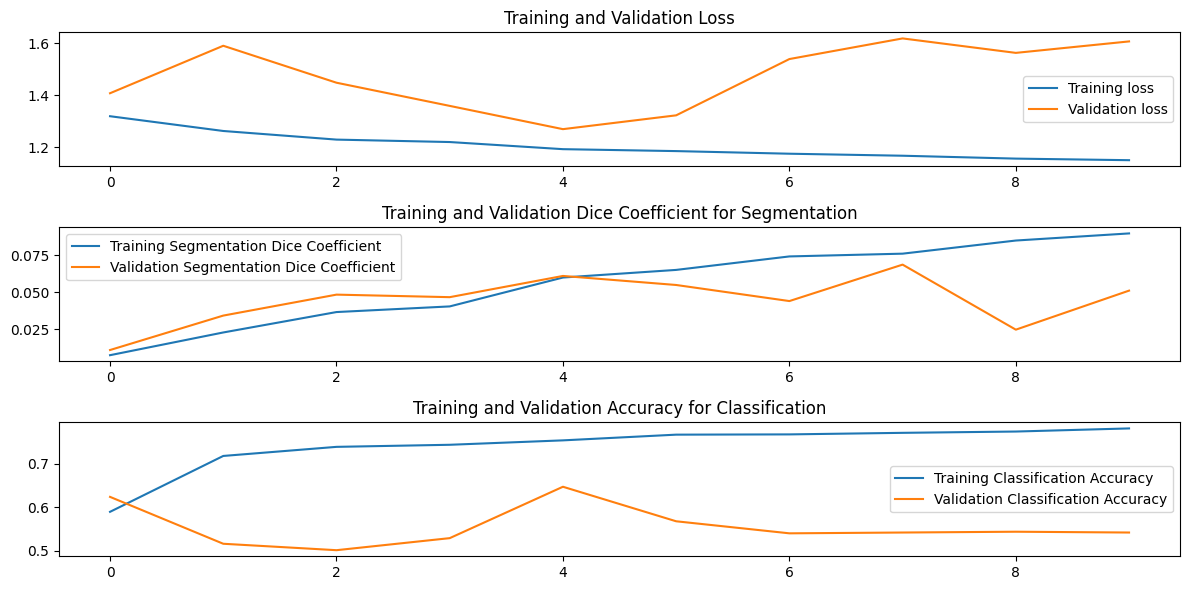


Epoch 10: val_loss did not improve from 1.27031
67/67 [==============================] - 46s 697ms/step - loss: 1.1512 - segmentation_loss: 0.9107 - classification_loss: 0.4810 - segmentation_dice_coefficient: 0.0895 - classification_accuracy: 0.7812 - val_loss: 1.6071 - val_segmentation_loss: 0.9490 - val_classification_loss: 1.3162 - val_segmentation_dice_coefficient: 0.0511 - val_classification_accuracy: 0.5416
Epoch 11/50
42/67 [=================>............] - ETA: 17s - loss: 1.1588 - segmentation_loss: 0.9167 - classification_loss: 0.4842 - segmentation_dice_coefficient: 0.0836 - classification_accuracy: 0.7691

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import BinaryAccuracy, MeanIoU
from tensorflow.keras.losses import BinaryCrossentropy

# Assuming PlotDualLosses and other necessary imports are defined elsewhere
epochs = 50
batch_size = 25  # Optimal batch size determined from experiments

# Fixed learning rate and loss weights
fixed_learning_rate = 0.001  # Replace with your chosen fixed learning rate
fixed_loss_weights = {'segmentation': 1.0, 'classification': 0.5}  # Replace with your chosen fixed loss weights

# Initialize and compile the model with current hyperparameters
model = extended_unet_model()
optimizer = Adam(learning_rate=fixed_learning_rate)
model.compile(
    optimizer=optimizer,
    loss={'segmentation': dice_loss, 'classification': bce_loss},
    loss_weights=fixed_loss_weights,
    metrics={'segmentation': dice_coefficient, 'classification': 'accuracy'}
)

# Setup callbacks
early_stopping = EarlyStopping(monitor='val_classification_accuracy', patience=5, verbose=1, restore_best_weights=True, mode='max')

early_stopping = EarlyStopping(monitor='val_loss', patience=7)

# Setup the plot losses callback
plot_dual_losses = PlotDualLosses()
from tensorflow.keras.callbacks import ModelCheckpoint

# Setup model checkpointing
checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)
# Fit the model
history = model.fit(
    train_generator(X_train, Y_seg_train, Y_class_train, batch_size),
    steps_per_epoch=len(X_train) // batch_size,
    validation_data=validation_generator(X_val, Y_seg_val, Y_class_val, batch_size),
    validation_steps=len(X_val) // batch_size,
    epochs=epochs,
    callbacks=[plot_dual_losses, early_stopping, checkpoint],
    verbose=1
)

# Extract the best validation accuracy achieved during the training
best_val_accuracy = np.max(history.history['val_classification_accuracy'])

print(f"Best validation accuracy with batch size {batch_size}:", best_val_accuracy)


In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import BinaryAccuracy, MeanIoU
from tensorflow.keras.losses import BinaryCrossentropy

# Assuming PlotDualLosses and other necessary imports are defined elsewhere
epochs = 50
batch_size = 25  # Optimal batch size determined from experiments

# Fixed learning rate and loss weights
fixed_learning_rate = 0.001  # Replace with your chosen fixed learning rate
fixed_loss_weights = {'segmentation': 1.0, 'classification': 0.5}  # Replace with your chosen fixed loss weights

# Initialize and compile the model with current hyperparameters
model = extended_unet_model()
optimizer = Adam(learning_rate=fixed_learning_rate)
model.compile(
    optimizer=optimizer,
    loss={'segmentation': dice_loss, 'classification': bce_loss},
    loss_weights=fixed_loss_weights,
    metrics={'segmentation': dice_coefficient, 'classification': 'accuracy'}
)

# Setup callbacks
early_stopping = EarlyStopping(monitor='val_segmentation_dice_coefficient', patience=8, verbose=1, restore_best_weights=True, mode='max')

early_stopping = EarlyStopping(monitor='val_loss', patience=8)
# Setup the plot losses callback
plot_dual_losses = PlotDualLosses()
from tensorflow.keras.callbacks import ModelCheckpoint

# Setup model checkpointing
checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)
# Fit the model
history = model.fit(
    train_generator(X_train, Y_seg_train, Y_class_train, batch_size),
    steps_per_epoch=len(X_train) // batch_size,
    validation_data=validation_generator(X_val, Y_seg_val, Y_class_val, batch_size),
    validation_steps=len(X_val) // batch_size,
    epochs=epochs,
    callbacks=[plot_dual_losses, early_stopping, checkpoint],
    verbose=1
)

# Extract the best validation accuracy achieved during the training
best_val_accuracy = np.max(history.history['val_classification_accuracy'])

print(f"Best validation accuracy: {batch_size}:", best_val_accuracy)


Epoch 1/50


ResourceExhaustedError: Graph execution error:

Detected at node model/concatenate_3/concat defined at (most recent call last):
  File "/usr/lib/python3.10/runpy.py", line 196, in _run_module_as_main

  File "/usr/lib/python3.10/runpy.py", line 86, in _run_code

  File "/usr/local/lib/python3.10/dist-packages/colab_kernel_launcher.py", line 37, in <module>

  File "/usr/local/lib/python3.10/dist-packages/traitlets/config/application.py", line 992, in launch_instance

  File "/usr/local/lib/python3.10/dist-packages/ipykernel/kernelapp.py", line 619, in start

  File "/usr/local/lib/python3.10/dist-packages/tornado/platform/asyncio.py", line 195, in start

  File "/usr/lib/python3.10/asyncio/base_events.py", line 603, in run_forever

  File "/usr/lib/python3.10/asyncio/base_events.py", line 1909, in _run_once

  File "/usr/lib/python3.10/asyncio/events.py", line 80, in _run

  File "/usr/local/lib/python3.10/dist-packages/tornado/ioloop.py", line 685, in <lambda>

  File "/usr/local/lib/

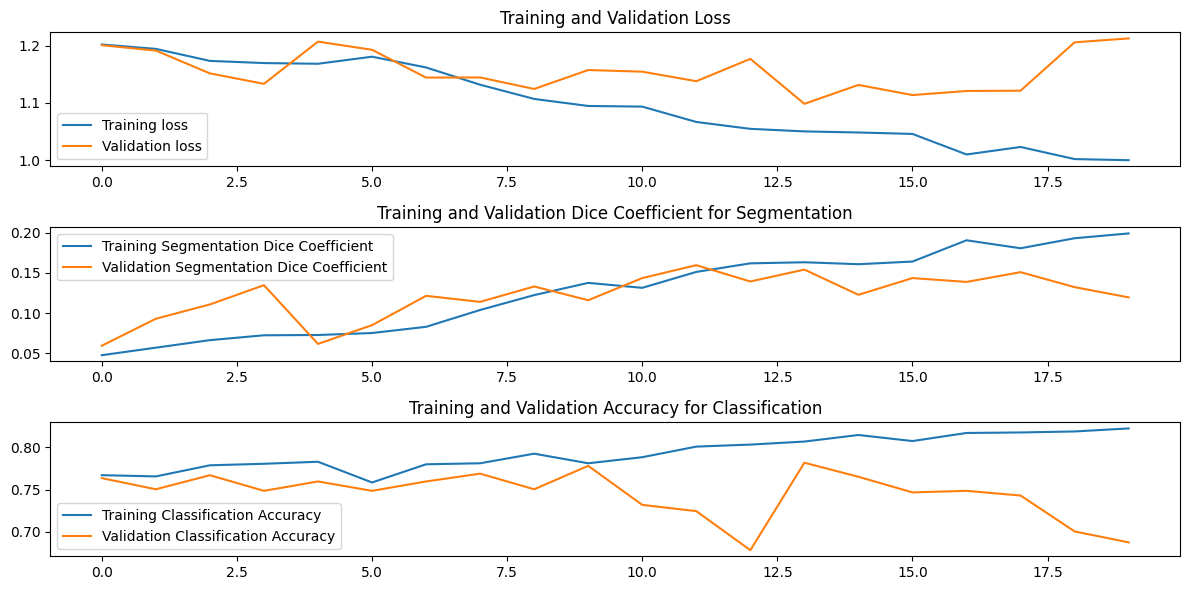

Restoring model weights from the end of the best epoch: 12.

Epoch 20: val_loss did not improve from 1.09844
67/67 [==============================] - 45s 681ms/step - loss: 1.0002 - segmentation_loss: 0.8009 - classification_loss: 0.3984 - segmentation_dice_coefficient: 0.1992 - classification_accuracy: 0.8225 - val_loss: 1.2124 - val_segmentation_loss: 0.8824 - val_classification_loss: 0.6602 - val_segmentation_dice_coefficient: 0.1196 - val_classification_accuracy: 0.6876
Epoch 20: early stopping
Best validation accuracy with batch size 25: 0.7818853855133057


In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import BinaryAccuracy, MeanIoU
from tensorflow.keras.losses import BinaryCrossentropy

# Assuming PlotDualLosses and other necessary imports are defined elsewhere
epochs = 50
batch_size = 25  # Optimal batch size determined from experiments

# Fixed learning rate and loss weights
fixed_learning_rate = 0.001  # Replace with your chosen fixed learning rate
fixed_loss_weights = {'segmentation': 1.0, 'classification': 0.5}  # Replace with your chosen fixed loss weights

# Initialize and compile the model with current hyperparameters
#model = extended_unet_model()
#optimizer = Adam(learning_rate=fixed_learning_rate)
#model.compile(
 #   optimizer=optimizer,
  #  loss={'segmentation': dice_loss, 'classification': bce_loss},
   # loss_weights=fixed_loss_weights,
    #metrics={'segmentation': dice_coefficient, 'classification': 'accuracy'}
#)

# Setup callbacks
early_stopping = EarlyStopping(monitor='val_segmentation_dice_coefficient', patience=8, verbose=1, restore_best_weights=True, mode='max')


# Setup the plot losses callback
#plot_dual_losses = PlotDualLosses()
#from tensorflow.keras.callbacks import ModelCheckpoint

# Setup model checkpointing
#checkpoint = ModelCheckpoint(
 #   'best_model.h5',
  #  monitor='val_loss',
   # save_best_only=True,
    #mode='min',
    #verbose=1
#)
# Fit the model
history = model.fit(
    train_generator(X_train, Y_seg_train, Y_class_train, batch_size),
    steps_per_epoch=len(X_train) // batch_size,
    validation_data=validation_generator(X_val, Y_seg_val, Y_class_val, batch_size),
    validation_steps=len(X_val) // batch_size,
    epochs=epochs,
    callbacks=[plot_dual_losses, early_stopping, checkpoint],
    verbose=1
)

# Extract the best validation accuracy achieved during the training
best_val_accuracy = np.max(history.history['val_classification_accuracy'])

print(f"Best validation accuracy with batch size {batch_size}:", best_val_accuracy)


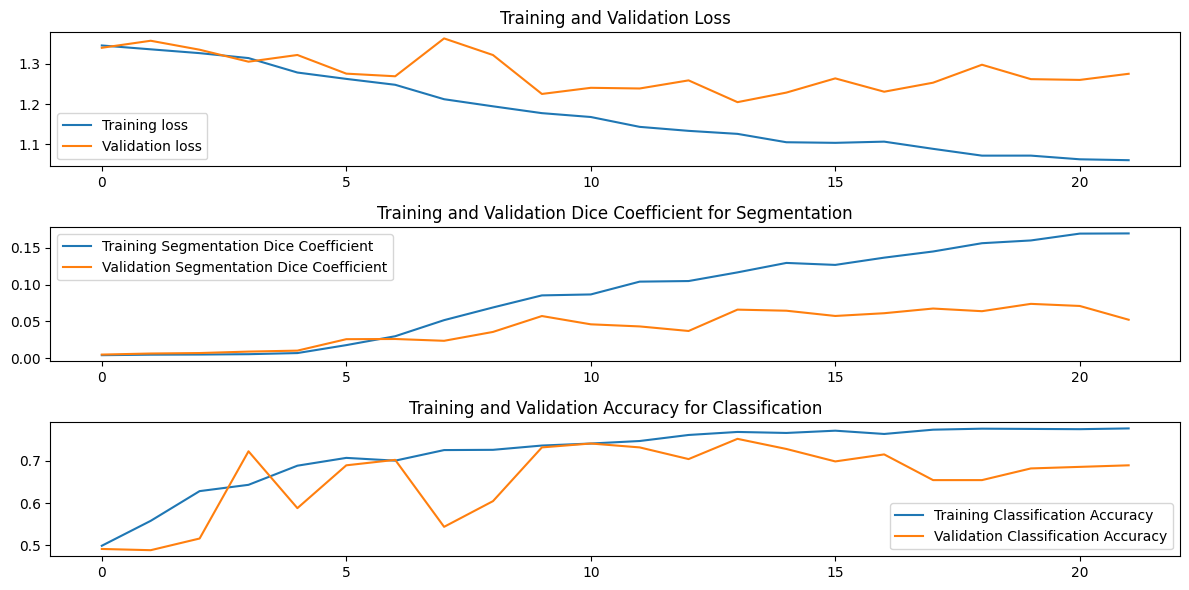


Epoch 22: val_loss did not improve from 1.20476
67/67 [==============================] - 45s 686ms/step - loss: 1.0603 - segmentation_loss: 0.8306 - classification_loss: 0.4596 - segmentation_dice_coefficient: 0.1696 - classification_accuracy: 0.7770 - val_loss: 1.2753 - val_segmentation_loss: 0.9486 - val_classification_loss: 0.6535 - val_segmentation_dice_coefficient: 0.0524 - val_classification_accuracy: 0.6895
Epoch 23/50
56/67 [========================>.....] - ETA: 7s - loss: 1.0572 - segmentation_loss: 0.8302 - classification_loss: 0.4540 - segmentation_dice_coefficient: 0.1701 - classification_accuracy: 0.7704

KeyboardInterrupt: 

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import BinaryAccuracy, MeanIoU
from tensorflow.keras.losses import BinaryCrossentropy

# Assuming PlotDualLosses and other necessary imports are defined elsewhere
epochs = 50
batch_size = 25  # Optimal batch size determined from experiments

# Fixed learning rate and loss weights
fixed_learning_rate = 0.001  # Replace with your chosen fixed learning rate
fixed_loss_weights = {'segmentation': 1.0, 'classification': 0.5}  # Replace with your chosen fixed loss weights

# Initialize and compile the model with current hyperparameters
model = extended_unet_model()
optimizer = Adam(learning_rate=fixed_learning_rate)
model.compile(
    optimizer=optimizer,
    loss={'segmentation': dice_loss, 'classification': bce_loss},
    loss_weights=fixed_loss_weights,
    metrics={'segmentation': dice_coefficient, 'classification': 'accuracy'}
)

# Setup callbacks
early_stopping = EarlyStopping(monitor='val_segmentation_dice_coefficient', patience=5, verbose=1, restore_best_weights=True, mode='max')

early_stopping = EarlyStopping(monitor='val_loss', patience=10)

# Setup the plot losses callback
plot_dual_losses = PlotDualLosses()
from tensorflow.keras.callbacks import ModelCheckpoint

# Setup model checkpointing
checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)
# Fit the model
history = model.fit(
    train_generator(X_train, Y_seg_train, Y_class_train, batch_size),
    steps_per_epoch=len(X_train) // batch_size,
    validation_data=validation_generator(X_val, Y_seg_val, Y_class_val, batch_size),
    validation_steps=len(X_val) // batch_size,
    epochs=epochs,
    callbacks=[plot_dual_losses, early_stopping, checkpoint],
    verbose=1
)

# Extract the best validation accuracy achieved during the training
best_val_accuracy = np.max(history.history['val_classification_accuracy'])

print(f"Best validation accuracy with batch size {batch_size}:", best_val_accuracy)


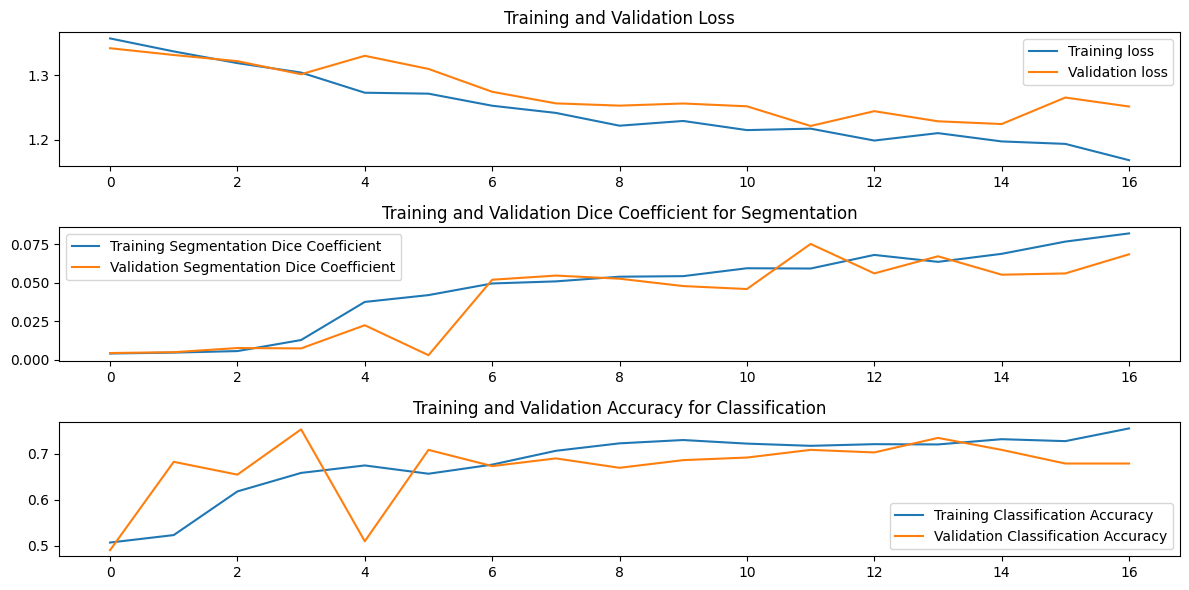

Restoring model weights from the end of the best epoch: 12.

Epoch 17: val_loss did not improve from 1.22132
67/67 [==============================] - 45s 686ms/step - loss: 1.1682 - segmentation_loss: 0.9183 - classification_loss: 0.4998 - segmentation_dice_coefficient: 0.0819 - classification_accuracy: 0.7543 - val_loss: 1.2515 - val_segmentation_loss: 0.9319 - val_classification_loss: 0.6393 - val_segmentation_dice_coefficient: 0.0683 - val_classification_accuracy: 0.6784
Epoch 17: early stopping
Best validation accuracy with batch size 25: 0.7523105144500732


In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import BinaryAccuracy, MeanIoU
from tensorflow.keras.losses import BinaryCrossentropy

# Assuming PlotDualLosses and other necessary imports are defined elsewhere
epochs = 50
batch_size = 25  # Optimal batch size determined from experiments

# Fixed learning rate and loss weights
fixed_learning_rate = 0.003  # Replace with your chosen fixed learning rate
fixed_loss_weights = {'segmentation': 1.0, 'classification': 0.5}  # Replace with your chosen fixed loss weights

# Initialize and compile the model with current hyperparameters
model = extended_unet_model()
optimizer = Adam(learning_rate=fixed_learning_rate)
model.compile(
    optimizer=optimizer,
    loss={'segmentation': dice_loss, 'classification': bce_loss},
    loss_weights=fixed_loss_weights,
    metrics={'segmentation': dice_coefficient, 'classification': 'accuracy'}
)

# Setup callbacks
early_stopping = EarlyStopping(monitor='val_segmentation_dice_coefficient', patience=5, verbose=1, restore_best_weights=True, mode='max')


# Setup the plot losses callback
plot_dual_losses = PlotDualLosses()
from tensorflow.keras.callbacks import ModelCheckpoint

# Setup model checkpointing
checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)
# Fit the model
history = model.fit(
    train_generator(X_train, Y_seg_train, Y_class_train, batch_size),
    steps_per_epoch=len(X_train) // batch_size,
    validation_data=validation_generator(X_val, Y_seg_val, Y_class_val, batch_size),
    validation_steps=len(X_val) // batch_size,
    epochs=epochs,
    callbacks=[plot_dual_losses, early_stopping, checkpoint],
    verbose=1
)

# Extract the best validation accuracy achieved during the training
best_val_accuracy = np.max(history.history['val_classification_accuracy'])

print(f"Best validation accuracy with batch size {batch_size}:", best_val_accuracy)


In [ ]:
model.summary()


Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 320, 320, 1)]        0         []                            
                                                                                                  
 conv2d_10 (Conv2D)          (None, 320, 320, 8)          80        ['input_2[0][0]']             
                                                                                                  
 leaky_re_lu_10 (LeakyReLU)  (None, 320, 320, 8)          0         ['conv2d_10[0][0]']           
                                                                                                  
 conv2d_11 (Conv2D)          (None, 320, 320, 8)          584       ['leaky_re_lu_10[0][0]']      
                                                                                            

In [ ]:
base_save_path = '/content/drive/My Drive/Semester 10/MS Dataset/My Models'
# Save the arrays
# Define the full path for saving the model
model_save_path = os.path.join(base_save_path, 'Multi-Head_U-Net2.keras')

# Save the model
model.save(model_save_path)

In [ ]:
from tensorflow.keras.models import load_model

# Load the model
# Load the model, specifying custom_objects

model = load_model('/content/drive/My Drive/Semester 10/MS Dataset/My Models/Multi-Head_U-Net.keras',
                   custom_objects={
                       'dice_loss': dice_loss,
                       'dice_coefficient': dice_coefficient,
                       'bce_loss': bce_loss  # Add this line
                   })

# Print model summary
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 320, 320, 1)]        0         []                            
                                                                                                  
 conv2d_10 (Conv2D)          (None, 320, 320, 8)          80        ['input_2[0][0]']             
                                                                                                  
 batch_normalization_10 (Ba  (None, 320, 320, 8)          32        ['conv2d_10[0][0]']           
 tchNormalization)                                                                                
                                                                                                  
 leaky_re_lu_10 (LeakyReLU)  (None, 320, 320, 8)          0         ['batch_normalization_10

In [11]:
# Prediction
predictions = model.predict(X_test)
#predicted_seg, predicted_class = predictions
predicted_seg = predictions

18/18 [==============================] - 2s 52ms/step


In [12]:
from sklearn.metrics import accuracy_score, classification_report

# Calculate accuracy for classification
classification_accuracy = accuracy_score(Y_class_test, predicted_class > 0.5)  # Using 0.5 as threshold for binary classification
print("Classification Accuracy:", classification_accuracy)

# For segmentation, you might use a custom Dice coefficient function or IoU
def dice_coefficient(true, pred, smooth=1):
    intersection = np.sum(pred * true)
    return (2. * intersection + smooth) / (np.sum(pred) + np.sum(true) + smooth)

# Calculate Dice Coefficient for each segmentation mask
dice_scores = [dice_coefficient(y_true, y_pred) for y_true, y_pred in zip(Y_seg_test, predicted_seg)]
mean_dice_score = np.mean(dice_scores)
print("Mean Dice Coefficient:", mean_dice_score)
print(classification_report(Y_class_test, predicted_class > 0.5))


NameError: name 'predicted_class' is not defined

In [13]:
from sklearn.metrics import accuracy_score, classification_report

# Calculate accuracy for classification
#classification_accuracy = accuracy_score(Y_class_test, predicted_class > 0.5)  # Using 0.5 as threshold for binary classification
#print("Classification Accuracy:", classification_accuracy)

# For segmentation, you might use a custom Dice coefficient function or IoU
def dice_coefficient(true, pred, smooth=1):
    intersection = np.sum(pred * true)
    return (2. * intersection + smooth) / (np.sum(pred) + np.sum(true) + smooth)



# Helper function to calculate IoU
def iou(true, pred, smooth=1):
    intersection = np.sum(pred * true)
    union = np.sum(pred) + np.sum(true) - intersection
    return (intersection + smooth) / (union + smooth)

# Helper functions for sensitivity and specificity
def sensitivity(true, pred):
    true_positive = np.sum(pred * true)
    false_negative = np.sum((pred == 0) * true)
    return true_positive / (true_positive + false_negative) if (true_positive + false_negative) > 0 else 0

def specificity(true, pred):
    true_negative = np.sum((pred == 0) * (true == 0))
    false_positive = np.sum(pred * (true == 0))
    return true_negative / (true_negative + false_positive) if (true_negative + false_positive) > 0 else 0

# Calculate Dice Coefficient for each segmentation mask
dice_scores = [dice_coefficient(y_true, y_pred) for y_true, y_pred in zip(Y_seg_test, predicted_seg)]
mean_dice_score = np.mean(dice_scores)
print("Mean Dice Coefficient:", mean_dice_score)

# Calculate IoU for each segmentation mask
iou_scores = [iou(y_true, y_pred) for y_true, y_pred in zip(Y_seg_test, predicted_seg)]
mean_iou_score = np.mean(iou_scores)
print("Mean IoU:", mean_iou_score)

# Calculate Sensitivity and Specificity
sensitivity_scores = [sensitivity(y_true, y_pred) for y_true, y_pred in zip(Y_seg_test, predicted_seg)]
mean_sensitivity = np.mean(sensitivity_scores)
print("Mean Sensitivity:", mean_sensitivity)

specificity_scores = [specificity(y_true, y_pred) for y_true, y_pred in zip(Y_seg_test, predicted_seg)]
mean_specificity = np.mean(specificity_scores)
print("Mean Specificity:", mean_specificity)



Mean Dice Coefficient: 0.13033796044567045
Mean IoU: 0.10999297589658052
Mean Sensitivity: 0.4973544973544973
Mean Specificity: 0.0


In [17]:
# Freeze all the layers in the pretrained model # for saved model leaky_re_lu_19
# Freeze all the layers in the pretrained model
for layer in model.layers:
    layer.trainable = False

# Assuming 'leaky_re_lu_19' is the output of your bottleneck
bottleneck_output = model.get_layer('leaky_re_lu_9').output

# Add a new Dense layer on top of the bottleneck
new_dense = Dense(3200, activation='relu', name='new_dense_layer')(bottleneck_output)

# Add a Dropout layer
new_dropout = Dropout(0.5)(new_dense)

new_pooling = GlobalAveragePooling2D()(new_dropout)
new_classification = Dense(1, activation='sigmoid', name='new_classification')(new_pooling)

# Create a new model with the new dense layer
new_model = Model(inputs=model.input, outputs=[model.get_layer('segmentation').output, new_classification])

# Compile the new model
new_model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss={'segmentation': 'mse', 'new_classification': 'binary_crossentropy'},
                  loss_weights={'segmentation': 0.0, 'new_classification': 1.0},  # Ignore segmentation loss
                  metrics={'new_classification': 'accuracy'})

# Print the summary to check the model structure
new_model.summary()


Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 320, 320, 1)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 320, 320, 8)          80        ['input_1[0][0]']             
                                                                                                  
 leaky_re_lu (LeakyReLU)     (None, 320, 320, 8)          0         ['conv2d[0][0]']              
                                                                                                  
 conv2d_1 (Conv2D)           (None, 320, 320, 8)          584       ['leaky_re_lu[0][0]']         
                                                                                            

In [18]:
# Train the model
history = new_model.fit(X_train, {'segmentation': Y_seg_train, 'new_classification': Y_class_train},
                        validation_data=(X_val, {'segmentation': Y_seg_val, 'new_classification': Y_class_val}),
                        epochs=50, batch_size=32,verbose = 1)


Epoch 1/50
54/54 [==============================] - 8s 110ms/step - loss: 0.7126 - segmentation_loss: 0.0019 - new_classification_loss: 0.7126 - new_classification_accuracy: 0.4994 - val_loss: 0.6822 - val_segmentation_loss: 0.0021 - val_new_classification_loss: 0.6822 - val_new_classification_accuracy: 0.5583
Epoch 2/50
54/54 [==============================] - 4s 81ms/step - loss: 0.6773 - segmentation_loss: 0.0019 - new_classification_loss: 0.6773 - new_classification_accuracy: 0.5718 - val_loss: 0.6654 - val_segmentation_loss: 0.0021 - val_new_classification_loss: 0.6654 - val_new_classification_accuracy: 0.6661
Epoch 3/50
54/54 [==============================] - 4s 82ms/step - loss: 0.6600 - segmentation_loss: 0.0019 - new_classification_loss: 0.6600 - new_classification_accuracy: 0.5883 - val_loss: 0.6766 - val_segmentation_loss: 0.0021 - val_new_classification_loss: 0.6766 - val_new_classification_accuracy: 0.5459
Epoch 4/50
54/54 [==============================] - 4s 81ms/step -

KeyboardInterrupt: 

In [ ]:
# Predict on a batch
predictions = model.predict(X_train[:batch_size])

# Print the type and shape of each output in the predictions list
for i, pred in enumerate(predictions):
    print(f"Shape of predictions from output {i}:", pred.shape)



1/1 [==============================] - 0s 22ms/step
Shape of predictions from output 0: (2, 320, 320, 1)
Shape of predictions from output 1: (2, 1)


In [ ]:
# Import the necessary function
from tensorflow.keras.losses import BinaryCrossentropy

# Initialize the loss function
loss_func = BinaryCrossentropy()

# Calculate loss for the segmentation output
seg_loss = loss_func(Y_seg_train[:batch_size], predictions[0])
print("Segmentation loss:", seg_loss.numpy())

# Calculate loss for the classification output
class_loss = loss_func(Y_class_train[:batch_size], predictions[1])
print("Classification loss:", class_loss.numpy())


Segmentation loss: nan
Classification loss: nan


In [ ]:
print("Unique values in segmentation labels:", np.unique(Y_seg_train[:batch_size]))
print("Unique values in classification labels:", np.unique(Y_class_train[:batch_size]))


Unique values in segmentation labels: [0.]
Unique values in classification labels: [0]


In [ ]:
print("Data type of X_train:", X_train.dtype)
print("Data type of Y_seg_train:", Y_seg_train.dtype)
print("Data type of Y_class_train:", Y_class_train.dtype)
# Assuming you have a preprocessing function applied like this:
X_processed = preprocess_data(X_train[0],Y_seg_train[0])
print("Data type after preprocessing X_train[0]:", X_processed.dtype)


Data type of X_train: float32
Data type of Y_seg_train: float32
Data type of Y_class_train: float32


ValueError: operands could not be broadcast together with remapped shapes [original->remapped]: (2,2)  and requested shape (3,2)